# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [ ]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
library(dplyr)
library(ggplot2)
url <- "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data <- read.csv(url, stringsAsFactors = FALSE)
nrow(raw_data)

[1] 7214


In [ ]:
%%R
head(raw_data, 10)

   id               name     first        last compas_screening_date    sex
1   1   miguel hernandez    miguel   hernandez            2013-08-14   Male
2   3        kevon dixon     kevon       dixon            2013-01-27   Male
3   4           ed philo        ed       philo            2013-04-14   Male
4   5        marcu brown     marcu       brown            2013-01-13   Male
5   6 bouthy pierrelouis    bouthy pierrelouis            2013-03-26   Male
6   7       marsha miles    marsha       miles            2013-11-30   Male
7   8      edward riddle    edward      riddle            2014-02-19   Male
8   9     steven stewart    steven     stewart            2013-08-30   Male
9  10   elizabeth thieme elizabeth      thieme            2014-03-16 Female
10 13          bo bradac        bo      bradac            2013-11-04   Male
          dob age         age_cat             race juv_fel_count decile_score
1  1947-04-18  69 Greater than 45            Other             0            1
2  1982-

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
%%R
numeric_vars  <- c("age", "priors_count", "days_b_screening_arrest",
                   "decile_score")
datetime_vars <- c("c_jail_in", "c_jail_out")

df <- dplyr::select(raw_data, age, c_charge_degree, race, age_cat,
                    score_text, sex, priors_count,
                    days_b_screening_arrest, decile_score, is_recid,
                    two_year_recid, c_jail_in, c_jail_out) %>%

      # ── Filtering ────────────────────────────────────────────────────
      filter(between(days_b_screening_arrest, -30, 30)) %>%
      filter(is_recid != -1) %>%
      filter(c_charge_degree != "O") %>%
      filter(score_text != "N/A") %>%

      # ── Type conversions ─────────────────────────────────────────────
      mutate(
        across(all_of(datetime_vars),
               ~ as.POSIXct(.x, format = "%Y-%m-%d %H:%M:%S", tz = "UTC")),
        across(-all_of(c(numeric_vars, datetime_vars)), as.factor)
      ) %>%

      # ── Derived factors with reference levels ─────────────────────────
      mutate(
        crime_factor  = factor(c_charge_degree),
        age_factor    = relevel(factor(age_cat),    ref = "25 - 45"),
        race_factor   = relevel(factor(race),       ref = "Caucasian"),
        gender_factor = relevel(factor(sex,
                          labels = c("Female", "Male")), ref = "Male"),
        score_factor  = factor(score_text != "Low",
                          labels = c("LowScore", "HighScore"))
      )
nrow(df)

[1] 6172


In [ ]:
%%R
head(df)

  age c_charge_degree             race         age_cat score_text  sex
1  69               F            Other Greater than 45        Low Male
2  34               F African-American         25 - 45        Low Male
3  24               F African-American    Less than 25        Low Male
4  44               M            Other         25 - 45        Low Male
5  41               F        Caucasian         25 - 45     Medium Male
6  43               F            Other         25 - 45        Low Male
  priors_count days_b_screening_arrest decile_score is_recid two_year_recid
1            0                      -1            1        0              0
2            0                      -1            3        1              1
3            4                      -1            4        1              1
4            0                       0            1        0              0
5           14                      -1            6        1              1
6            3                      -1         

In [ ]:
%%R
glimpse(df)

Rows: 6,172
Columns: 18
$ age                     <int> 69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47…
$ c_charge_degree         <fct> F, F, F, M, F, F, M, F, M, M, F, F, F, M, F, F…
$ race                    <fct> Other, African-American, African-American, Oth…
$ age_cat                 <fct> Greater than 45, 25 - 45, Less than 25, 25 - 4…
$ score_text              <fct> Low, Low, Low, Low, Medium, Low, Low, Low, Med…
$ sex                     <fct> Male, Male, Male, Male, Male, Male, Female, Ma…
$ priors_count            <int> 0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1, 7, 0, 3, …
$ days_b_screening_arrest <int> -1, -1, -1, 0, -1, -1, -1, -1, 0, 0, -1, -20, …
$ decile_score            <int> 1, 3, 4, 1, 6, 4, 1, 4, 6, 1, 4, 1, 3, 1, 10, …
$ is_recid                <fct> 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1…
$ two_year_recid          <fct> 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1…
$ c_jail_in               <dttm> 2013-08-13 06:03:42, 2013-01-26 03:45:27, 201…
$ c_jail_out    

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
%%R
df$length_of_stay <- as.numeric(as.Date(df$c_jail_out) - as.Date(df$c_jail_in))
cor(df$length_of_stay, df$decile_score)

[1] 0.2073297


After filtering we have the following demographic breakdown:

In [ ]:
%%R
summary(df$age_cat)

        25 - 45 Greater than 45    Less than 25 
           3532            1293            1347 


In [ ]:
%%R
summary(df$race)

African-American            Asian        Caucasian         Hispanic 
            3175               31             2103              509 
 Native American            Other 
              11              343 


In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
%%R
summary(df$score_text)

  High    Low Medium 
  1144   3421   1607 


In [ ]:
%%R
xtabs(~ sex + race, data=df)

        race
sex      African-American Asian Caucasian Hispanic Native American Other
  Female              549     2       482       82               2    58
  Male               2626    29      1621      427               9   285


In [ ]:
%%R
summary(df$sex)

Female   Male 
  1175   4997 


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
%%R
nrow(filter(df, two_year_recid == 1))

[1] 2809


In [ ]:
%%R
nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100

[1] 45.51199


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.tar.gz'
Content type 'application/x-gzip' length 1062844 bytes (1.0 MB)
downloaded 1.0 MB


The downloaded source packages are in
	‘/tmp/RtmpdTRaRj/downloaded_packages’


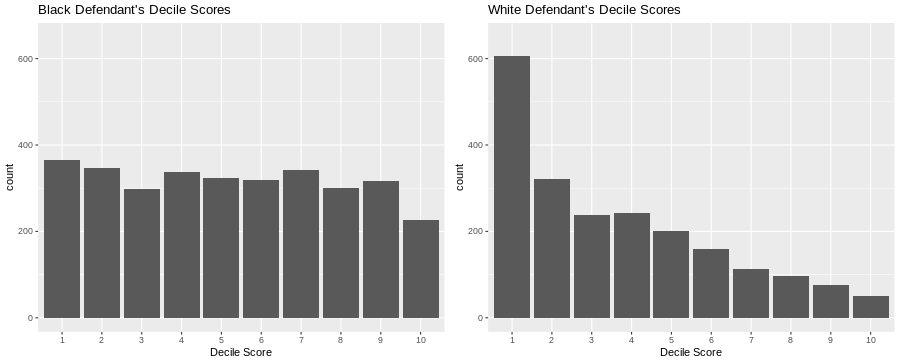

In [ ]:
%%R -w 900 -h 363 -u px
install.packages("gridExtra")
library(grid)
library(gridExtra)
pblack <- ggplot(data=filter(df, race =="African-American"), aes(ordered(decile_score))) +
          geom_bar() + xlab("Decile Score") +
          ylim(0, 650) + ggtitle("Black Defendant's Decile Scores")
pwhite <- ggplot(data=filter(df, race =="Caucasian"), aes(ordered(decile_score))) +
          geom_bar() + xlab("Decile Score") +
          ylim(0, 650) + ggtitle("White Defendant's Decile Scores")
grid.arrange(pblack, pwhite,  ncol = 2)

In [ ]:
%%R
xtabs(~ decile_score + race, data=df)

            race
decile_score African-American Asian Caucasian Hispanic Native American Other
          1               365    15       605      159               0   142
          2               346     4       321       89               2    60
          3               298     5       238       73               1    32
          4               337     0       243       47               0    39
          5               323     1       200       39               0    19
          6               318     2       160       27               2    20
          7               343     1       113       28               2     9
          8               301     2        96       14               0     7
          9               317     0        77       17               2     7
          10              227     1        50       16               2     8


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [ ]:
%%R
model_glm <- glm(score_factor ~ gender_factor + age_factor + race_factor +
                            priors_count + crime_factor + two_year_recid, data   = df, family = binomial(link = "logit"))
summary(model_glm)


Call:
glm(formula = score_factor ~ gender_factor + age_factor + race_factor + 
    priors_count + crime_factor + two_year_recid, family = binomial(link = "logit"), 
    data = df)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -1.52554    0.07851 -19.430  < 2e-16 ***
gender_factorFemale          0.22127    0.07951   2.783 0.005388 ** 
age_factorGreater than 45   -1.35563    0.09908 -13.682  < 2e-16 ***
age_factorLess than 25       1.30839    0.07593  17.232  < 2e-16 ***
race_factorAfrican-American  0.47721    0.06935   6.881 5.93e-12 ***
race_factorAsian            -0.25441    0.47821  -0.532 0.594717    
race_factorHispanic         -0.42839    0.12813  -3.344 0.000827 ***
race_factorNative American   1.39421    0.76612   1.820 0.068784 .  
race_factorOther            -0.82635    0.16208  -5.098 3.43e-07 ***
priors_count                 0.26895    0.01110  24.221  < 2e-16 ***
crime_factorM               -0.31124    0.066

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
%%R
control <- exp(-1.52554) / (1 + exp(-1.52554))
exp(0.47721) / (1 - control + (control * exp(0.47721)))

[1] 1.452841


Women are 19.4% more likely than men to get a higher score.

In [ ]:
%%R
exp(0.22127) / (1 - control + (control * exp(0.22127)))

[1] 1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
%%R
exp(1.30839) / (1 - control + (control * exp(1.30839)))

[1] 2.49612


In [ ]:
%%R
df <- df %>%
  mutate(
    pred_prob  = predict(model_glm, type = "response"),
    pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0),
                        levels = c(0, 1),
                        labels = c("No Recid", "Recid"))
  )

In [ ]:
%%R
cat("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm <- table(
  Predicted = df$pred_class,
  Actual    = df$two_year_recid
)
print(overall_cm)

# Overall metrics
TP  <- overall_cm["Recid",    "1"]
TN  <- overall_cm["No Recid", "0"]
FP  <- overall_cm["Recid",    "0"]
FN  <- overall_cm["No Recid", "1"]
n   <- sum(overall_cm)

cat(sprintf("\nAccuracy  : %.3f", (TP + TN) / n))
cat(sprintf("\nPrecision : %.3f", TP / (TP + FP)))
cat(sprintf("\nRecall    : %.3f", TP / (TP + FN)))
cat(sprintf("\nFPR       : %.3f", FP / (FP + TN)))
cat(sprintf("\nFNR       : %.3f", FN / (FN + TP)))


── Overall Confusion Matrix ──────────────────────────────────────────
          Actual
Predicted     0    1
  No Recid 2653  945
  Recid     710 1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336

In [ ]:
%%R
cat("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

race_metrics <- df %>%
  mutate(
    actual = as.integer(as.character(two_year_recid)),
    pred   = as.integer(pred_class == "Recid")
  ) %>%
  group_by(race) %>%
  summarise(
    n         = n(),
    TP        = sum( pred == 1 &  actual == 1),
    TN        = sum( pred == 0 &  actual == 0),
    FP        = sum( pred == 1 &  actual == 0),
    FN        = sum( pred == 0 &  actual == 1),
    Accuracy  = round((TP + TN) / n, 3),
    Precision = round(TP / (TP + FP), 3),
    Recall    = round(TP / (TP + FN), 3),
    FPR       = round(FP / (FP + TN), 3),
    FNR       = round(FN / (FN + TP), 3),
    .groups   = "drop"
  ) %>%
  arrange(desc(n))

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────
# A tibble: 6 × 11
  race           n    TP    TN    FP    FN Accuracy Precision Recall   FPR   FNR
  <fct>      <int> <int> <int> <int> <int>    <dbl>     <dbl>  <dbl> <dbl> <dbl>
1 African-A…  3175  1373   959   555   288    0.734     0.712  0.827 0.367 0.173
2 Caucasian   2103   381  1148   133   441    0.727     0.741  0.464 0.104 0.536
3 Hispanic     509    81   306    14   108    0.76      0.853  0.429 0.044 0.571
4 Other        343    22   216     3   102    0.694     0.88   0.177 0.014 0.823
5 Asian         31     2    22     1     6    0.774     0.667  0.25  0.043 0.75 
6 Native Am…    11     5     2     4     0    0.636     0.556  1     0.667 0    


In [ ]:
%%R
cat("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

disparity <- race_metrics %>%
  dplyr::select(race, n, FPR, FNR) %>%
  mutate(
    delta_FPR = round(FPR - FPR[race == "Caucasian"], 3),
    delta_FNR = round(FNR - FNR[race == "Caucasian"], 3)
  )

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────
# A tibble: 6 × 6
  race                 n   FPR   FNR delta_FPR delta_FNR
  <fct>            <int> <dbl> <dbl>     <dbl>     <dbl>
1 African-American  3175 0.367 0.173     0.263    -0.363
2 Caucasian         2103 0.104 0.536     0         0    
3 Hispanic           509 0.044 0.571    -0.06      0.035
4 Other              343 0.014 0.823    -0.09      0.287
5 Asian               31 0.043 0.75     -0.061     0.214
6 Native American     11 0.667 0         0.563    -0.536
